In [91]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Load data

In [92]:
df = pd.read_csv("data/sve.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df
    .sort_values("Date")
    .reset_index(drop=True)
)

df.head()

,Date,CPI,HICP,GER2Y,GER10Y,USA2Y,USA10Y,EURUSD
0,1999-01-01,164.7,57.07,3.071,3.863,4.575,4.677,1.1680
1,1999-01-02,164.7,57.07,3.071,3.863,4.575,4.677,1.1680
2,1999-01-03,164.7,57.07,3.071,3.863,4.575,4.677,1.1680
3,1999-01-04,164.7,57.07,3.071,3.748,4.575,4.677,1.1812
4,1999-01-05,164.7,57.07,3.089,3.791,4.641,4.745,1.1755


## ok

In [93]:
df["EURUSD_return"] = (
    df["EURUSD"]
    .pct_change()
)

lags = [
    1,      # yesterday
    7,      # one week
    30,     # one month
    90,     # quarter
    365     # year
]


for lag in lags:

    df[f"EURUSD_return_mean_{lag}"] = (
        np.mean(df["EURUSD_return"][-lag:])
    )


In [94]:
df = df.dropna()

df.shape

(10013, 14)

## Feature Engineering

In [95]:
features = [
    c for c in df.columns
    if c not in [
        "Date"
    ]
]


X = df[features]

y = df["EURUSD_return"].shift(-1)


df = df.iloc[:-1]

X = X.iloc[:-1]
y = y.iloc[:-1]


print(X.shape)
print(y.shape)

(10012, 13)
(10012,)


In [96]:
print(features)

['CPI', 'HICP', 'GER2Y', 'GER10Y', 'USA2Y', 'USA10Y', 'EURUSD', 'EURUSD_return', 'EURUSD_return_mean_1', 'EURUSD_return_mean_7', 'EURUSD_return_mean_30', 'EURUSD_return_mean_90', 'EURUSD_return_mean_365']


## train test split

In [97]:
split = int(len(X)*0.8)


X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

dates_test = df["Date"].iloc[split:]

## Normalizacija

In [98]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Train Ridge regression

In [99]:
model = Ridge(
    alpha=100
)


model.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

## Predikcija

In [100]:
pred_return = model.predict(
    X_test_scaled
)

## Metrike

In [101]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_return
    )
)

mae = mean_absolute_error(
    y_test,
    pred_return
)

r2 = r2_score(
    y_test,
    pred_return
)


print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

RMSE: 0.0043038987837024185
MAE : 0.0031331996561111326
R²  : -0.0924226861592452


## Konvertovanje nazad u EUR/RSD

In [ ]:
actual_prices = df["EURUSD"].iloc[split:].values


predicted_prices = []

price = actual_prices[0]


for r in pred_return:
    price = price * (1+r)

    predicted_prices.append(price)


predicted_prices = np.array(
    predicted_prices
)

-8.096540779234237e-07
1.2901863755657948e-05
-3.3281622692754526e-06
5.946048046334339e-05
-0.00015349025716896448
4.8198927400909284e-05
-1.6543516550468012e-05
-6.237173957730192e-05
-4.8736457092425544e-05
-2.8331343849136196e-05
-0.00010133427352855289
-0.000167527106638156
-1.0061540444385527e-05
-2.5235466045307606e-05
6.497511105545407e-05
-6.491196998714638e-05
8.784630427367044e-05
-1.502356511548821e-05
1.9637251610821688e-05
6.799783364074719e-05
3.457361027531622e-06
-0.00011994216817360296
-4.6338106328837475e-05
-9.490532984564736e-05
-0.00012914172120815409
0.0006955943223127302
-3.0477674703790813e-05
2.8126266431508283e-05
-0.0005322604633685394
-2.225896840477507e-05
-0.00013520875629577673
-0.0001221597182146772
0.00011304999631043309
8.697263624525516e-05
-3.243778353851299e-05
5.8310414533299684e-05
4.301487996933159e-05
-0.0001109612196702198
8.815981743455792e-05
-7.904569454501272e-07
0.00015831533428878957
-3.4475251559855308e-06
1.4517452918197996e-05
-2.2546

## Grafički prikaz

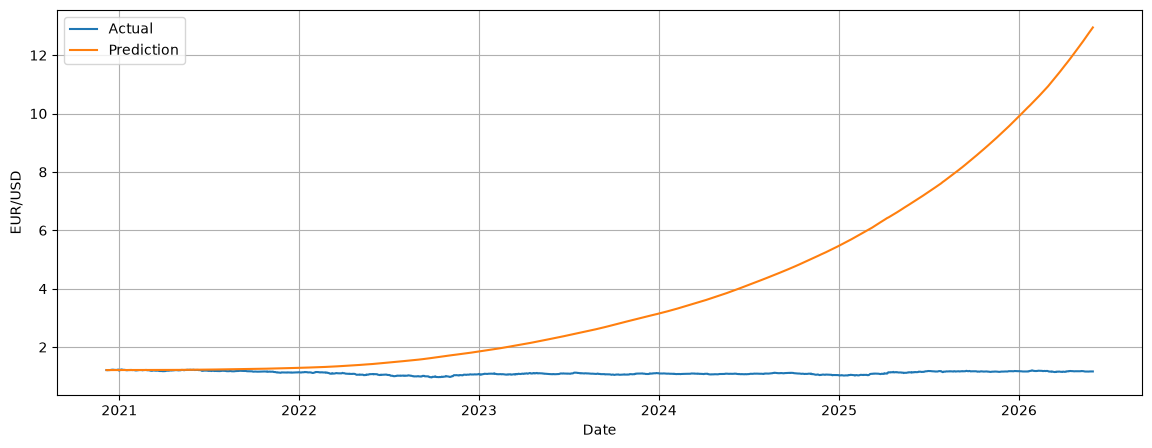

In [103]:
plt.figure(figsize=(14,5))


plt.plot(
    dates_test,
    actual_prices,
    label="Actual"
)


plt.plot(
    dates_test,
    predicted_prices,
    label="Prediction"
)


plt.xlabel("Date")
plt.ylabel("EUR/USD")


plt.legend()
plt.grid(True)


plt.show()

## Koeficijenti

In [104]:
importance = pd.DataFrame({

    "Feature": features,

    "Coefficient": model.coef_

})


importance["abs"] = (
    importance["Coefficient"]
    .abs()
)


importance.sort_values(
    "abs",
    ascending=False
).head(20)

,Feature,Coefficient,abs
3,GER10Y,0.000623,0.000623
1,HICP,0.000398,0.000398
6,EURUSD,-0.000265,0.000265
5,USA10Y,-0.000250,0.000250
7,EURUSD_return,-0.000135,0.000135
0,CPI,0.000042,0.000042
4,USA2Y,-0.000033,0.000033
2,GER2Y,0.000029,0.000029
8,EURUSD_return_mean_1,0.000000,0.000000
9,EURUSD_return_mean_7,0.000000,0.000000


In [105]:
print(x_train_scaled.head(5))

NameError: name 'x_train_scaled' is not defined

## Trial and error

In [ ]:
for alpha in [
    0.1,
    1,
    10,
    100,
    1000
]:

    model_test = Ridge(alpha=alpha)

    model_test.fit(
        X_train_scaled,
        y_train
    )

    pred = model_test.predict(
        X_test_scaled
    )

    print(
        "alpha:",
        alpha,
        "RMSE:",
        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),
        "R2:",
        r2_score(
            y_test,
            pred
        )
    )

alpha: 0.1 RMSE: 0.004123175021654127 R2: -0.02143202888762552
alpha: 1 RMSE: 0.004122955392419526 R2: -0.021323214511005606
alpha: 10 RMSE: 0.004121140111429623 R2: -0.02042406315161216
alpha: 100 RMSE: 0.0041145813510541545 R2: -0.017178654828200468
alpha: 1000 RMSE: 0.004100798895413159 R2: -0.010375659007597182
